# Bavian-data og Site Frequency Spectrum

Formål: 

I Notebook 1–2 arbejdede jeg med simulerede data. Nu introducerer jeg de *rigtige bavian-data*, som resten af specialet bygger på.

I denne notebook kommer jeg ind på:

1. **Forstå datasættet** — hvilke populationer, hvor mange individer, hvilke kromosomer?
2. **Beregne Site Frequency Spectrum (SFS)** 


Jeg arbejder med to bavianpopulationer fra Etiopien:

| Population | Art | Lokalitet |
|---|---|---|
| **GOG** | *Papio anubis* (oliven bavian) | Gog, Etiopien |
| **Filoha** | *Papio hamadryas* (hamadryas bavian) | Filoha, Etiopien |

Disse to populationer lever i hybrid-zonen for de to arter og er interessante fordi der observeres hybridisering. SFS-formen vil afsløre, om de to populationer har forskellig historik fx forskellig effektiv populationsstørrelse eller tegn på admixture.

I Notebook 01 beregnede jeg det *forventede* SFS under en simpel coalescent-model. Her beregner jeg det *observerede* SFS fra data. I Notebook 04–06 tilpasser jeg modellerne, så de passer til det observerede SFS.

In [1]:
# Importer nødvendige pakker
# phasic importeres først for at sætte JAX-backend korrekt
from phasic import Graph, with_ipv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from vscodenb import set_vscode_theme

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

## 1. Indlæsning af genomdata

Datasættet er phased VCF-data i Zarr-format for kromosom 20, indlæst via `sgkit`. Phased data betyder, at jeg kender haplotyperne dvs. jeg ved hvilke alleler der sidder på samme kromosom. Dette er vigtigt for vores modeller, der arbejder med haploide linjer.

Kromosom 20 er valgt som udgangspunkt fordi det er et autosomalt kromosom af mellemstørrelse, ingen X/Y-komplikationer og tilstrækkeligt informativt.

In [2]:
# Indlæs genomdata for kromosom 20
ds = sg.load_dataset(
    "/faststorage/project/baboondiversity/data/"
    "PG_panu3_phased_chromosomes_4_7_2021_ZARR/chr20.phased.rehead.vcz"
)

print(f"Antal samples:   {ds.dims['samples']}")
print(f"Antal varianter: {ds.dims['variants']:,}")
print()
ds

Antal samples:   227
Antal varianter: 2,665,269



/tmp/ipykernel_1252416/3643734802.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Antal samples:   {ds.dims['samples']}")
/tmp/ipykernel_1252416/3643734802.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Antal varianter: {ds.dims['variants']:,}")


<xarray.Dataset> Size: 3GB
Dimensions:               (variants: 2665269, samples: 227, ploidy: 2,
                           contigs: 1, filters: 1, region_index_values: 2666,
                           region_index_fields: 6, alt_alleles: 1, alleles: 2)
Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                region_index_values, region_index_fields,
                                alt_alleles, alleles
Data variables: (12/19)
    call_genotype         (variants, samples, ploidy) int8 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_mask    (variants, samples, ploidy) bool 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_phased  (variants, samples) bool 605MB dask.array<chunksize=(1000, 227), meta=np.ndarray>
    contig_id             (contigs) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_description    (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_id             (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                    ...
    variant_filter        (variants, filters) bool 3MB dask.array<chunksize=(1000, 1), meta=np.ndarray>
    variant_id            (variants) object 21MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_id_mask       (variants) bool 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_length        (variants) int8 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_position      (variants) int32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_quality       (variants) float32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
Attributes:
    source:                bio2zarr-0.1.7
    vcf_meta_information:  [['fileformat', 'VCFv4.2'], ['fileDate', '06/07/20...
    vcf_zarr_version:      0.4

In [3]:
# Undersøg sample IDs for at forstå navngivning
sample_ids = ds["sample_id"].values
print(f"Første 10 sample IDs: {sample_ids[:10]}")
print(f"Sidste 10 sample IDs: {sample_ids[-10:]}")

Første 10 sample IDs: ['Sci_16066' 'Sci_16098' 'Sci_30877' 'Sci_30977' 'Sci_34449' 'Sci_34474'
 'Sci_38168' 'Sci_97074' 'Sci_97124' 'PD_0067']
Sidste 10 sample IDs: ['PD_0785' 'PD_0786' 'PD_0787' 'PD_0788' 'PD_0789' 'PD_0790' 'PD_0791'
 'PD_0792' 'PD_0793' 'PD_0794_BAB']


## 2. Udvælgelse af populationer

Jeg udtrækker de to fokuspopulationer fra det samlede datasæt. Sample IDs er præ-identificerede som tilhørende GOG (*P. anubis*) og Filoha (*P. hamadryas*).

**GOG**: 25 individer, Gog, Etiopien — oliven bavian (*P. anubis*)

**Filoha**: 24 individer, Filoha, Etiopien — hamadryas bavian (*P. hamadryas*)

In [5]:
# Definition af de to populationer
gog_samples = [
    'PD_0720', 'PD_0721', 'PD_0722', 'PD_0723', 'PD_0724', 'PD_0725', 'PD_0726',
    'PD_0727', 'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733',
    'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738', 'PD_0739', 'PD_0740',
    'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744'
]

filoha_samples = [
    'PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701', 'PD_0702',
    'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
    'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 'PD_0716',
    'PD_0717', 'PD_0718', 'PD_0719'
]

# Subset datasættet
mask_gog    = ds["sample_id"].isin(gog_samples).values
mask_filoha = ds["sample_id"].isin(filoha_samples).values

ds_gog    = ds.isel(samples=mask_gog)
ds_filoha = ds.isel(samples=mask_filoha)

print(f"GOG:    {ds_gog.dims['samples']} individer × {ds_gog.dims['variants']:,} varianter")
print(f"Filoha: {ds_filoha.dims['samples']} individer × {ds_filoha.dims['variants']:,} varianter")

GOG:    25 individer × 2,665,269 varianter
Filoha: 24 individer × 2,665,269 varianter


/tmp/ipykernel_1252416/4132448237.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"GOG:    {ds_gog.dims['samples']} individer × {ds_gog.dims['variants']:,} varianter")
/tmp/ipykernel_1252416/4132448237.py:24: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Filoha: {ds_filoha.dims['samples']} individer × {ds_filoha.dims['variants']:,} varianter")


## 3. Beregning af derived allele counts

For at konstruere SFS skal jeg for hver variant vide, hvor mange individer der bærer den afledte allel (den allel der opstod ved mutation, modsat den ancestrale allel). Dette tal kaldes *derived allele count* (DAC).

Datasættet er polariseret. Jeg antager at referenceallellet er ancestralt og det alternative allel er deriveret. Dette er en simplificerende antagelse, som er standard i coalescent-analyser.

For *n* diploide individer vil DAC ligge mellem 0 (ingen bærer den afledte allel) og 2*n* (alle bærer den).

In [8]:
def compute_derived_counts(ds_sub):
    """
    Beregn antal derived alleler per variant.
    
    Returnerer DataFrame med position, derived allele count og antal haploide kromosomer.
    Jeg ekskluderer faste varianter (DAC=0 eller DAC=n) da disse ikke bidrager til SFS.
    """
    variant_allele_counts = sg.count_variant_alleles(ds_sub)
    ac = variant_allele_counts["variant_allele_count"].values
    nr_chromosomes = ac.sum(axis=1)

    df = pd.DataFrame({
        "position":      ds_sub["variant_position"].values,
        "derived_count": ac[:, 1],
        "nr_chromosomes": nr_chromosomes,
    })

    # Behold kun segregerende varianter (0 < DAC < total)
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_chromosomes"])]
    return df.reset_index(drop=True)

df_gog    = compute_derived_counts(ds_gog)
df_filoha = compute_derived_counts(ds_filoha)

print(f"GOG:    {len(df_gog):,} segregerende varianter")
print(f"Filoha: {len(df_filoha):,} segregerende varianter")
print()
print("GOG — de første 5 varianter:")
df_gog.head()
print("Filoha — de første 5 varianter:")
df_filoha.head()

GOG:    528,250 segregerende varianter
Filoha: 460,025 segregerende varianter

GOG — de første 5 varianter:
Filoha — de første 5 varianter:


,position,derived_count,nr_chromosomes
0,501,17,48
1,953,12,48
2,1971,4,48
3,2144,10,48
4,2189,3,48


In [9]:
print("Filoha — de første 5 varianter:")
df_filoha.head()

Filoha — de første 5 varianter:


,position,derived_count,nr_chromosomes
0,501,17,48
1,953,12,48
2,1971,4,48
3,2144,10,48
4,2189,3,48


## 4. Site Frequency Spectrum (SFS)

SFS er en fordeling der tæller, hvor mange varianter der optræder med præcis *k* kopier i prøven. 

- **Mange singletons** (k=1): Indikerer population-ekspansion eller purifying selection
- **Mange høj-frekvens varianter**: Kan indikere balancerende selektion eller admixture
- **Symmetrisk SFS**: Konsistent med konstant populationsstørrelse

SFS er det jeg beregnede *teoretisk* i Notebook 1 via rewards. Nu beregner jeg det *empirisk* fra data.

In [10]:
def compute_sfs(df):
    """Tæl antal varianter per derived allele count."""
    return df["derived_count"].value_counts().sort_index()

sfs_gog    = compute_sfs(df_gog)
sfs_filoha = compute_sfs(df_filoha)

print("SFS for GOG (rå tal):")
print(sfs_gog.to_string())

SFS for GOG (rå tal):
derived_count
1     93227
2     58324
3     41084
4     32810
5     27122
6     21614
7     18582
8     15229
9     13932
10    12296
11    11874
12     9958
13     9161
14     9668
15     8996
16     8479
17     8647
18     6178
19     5819
20     5356
21     5898
22     5518
23     5139
24     4837
25     5760
26     4557
27     4062
28     3960
29     4055
30     4036
31     3624
32     3337
33     3759
34     3683
35     3447
36     2934
37     3474
38     3111
39     3072
40     2742
41     2786
42     3163
43     2874
44     2907
45     2978
46     3226
47     3363
48     3548
49     4044


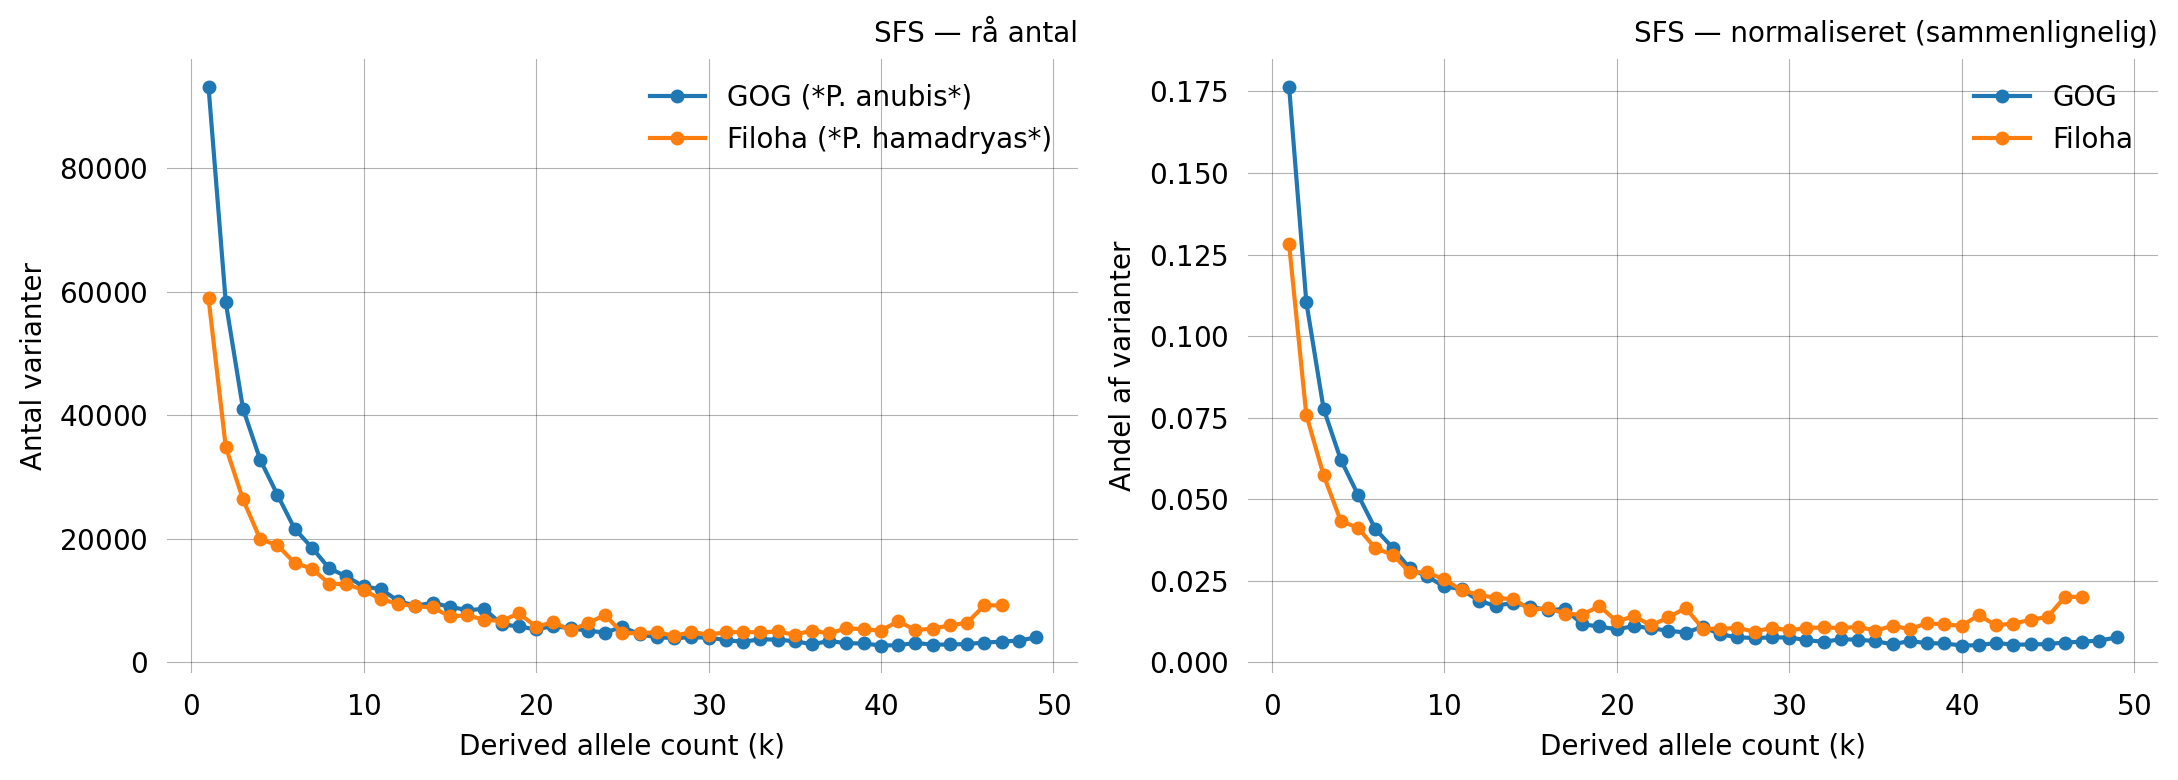

In [11]:
# Visualiser rå SFS for begge populationer
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(sfs_gog.index,    sfs_gog.values,    marker='o', ms=4, label='GOG (*P. anubis*)')
axes[0].plot(sfs_filoha.index, sfs_filoha.values, marker='o', ms=4, label='Filoha (*P. hamadryas*)')
axes[0].set_xlabel("Derived allele count (k)")
axes[0].set_ylabel("Antal varianter")
axes[0].set_title("SFS — rå antal")
axes[0].legend()

# Normaliseret SFS gør det muligt at sammenligne på tværs af stikprøvestørrelser
def normalize_sfs(sfs):
    return sfs / sfs.sum()

axes[1].plot(normalize_sfs(sfs_gog).index,    normalize_sfs(sfs_gog).values,    marker='o', ms=4, label='GOG')
axes[1].plot(normalize_sfs(sfs_filoha).index, normalize_sfs(sfs_filoha).values, marker='o', ms=4, label='Filoha')
axes[1].set_xlabel("Derived allele count (k)")
axes[1].set_ylabel("Andel af varianter")
axes[1].set_title("SFS — normaliseret (sammenlignelig)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Fortolkning af SFS

Jeg sammenligner det observerede SFS med det forventede under en **standard neutral coalescent** (konstant populationsstørrelse, ingen selektion, ingen admixture).

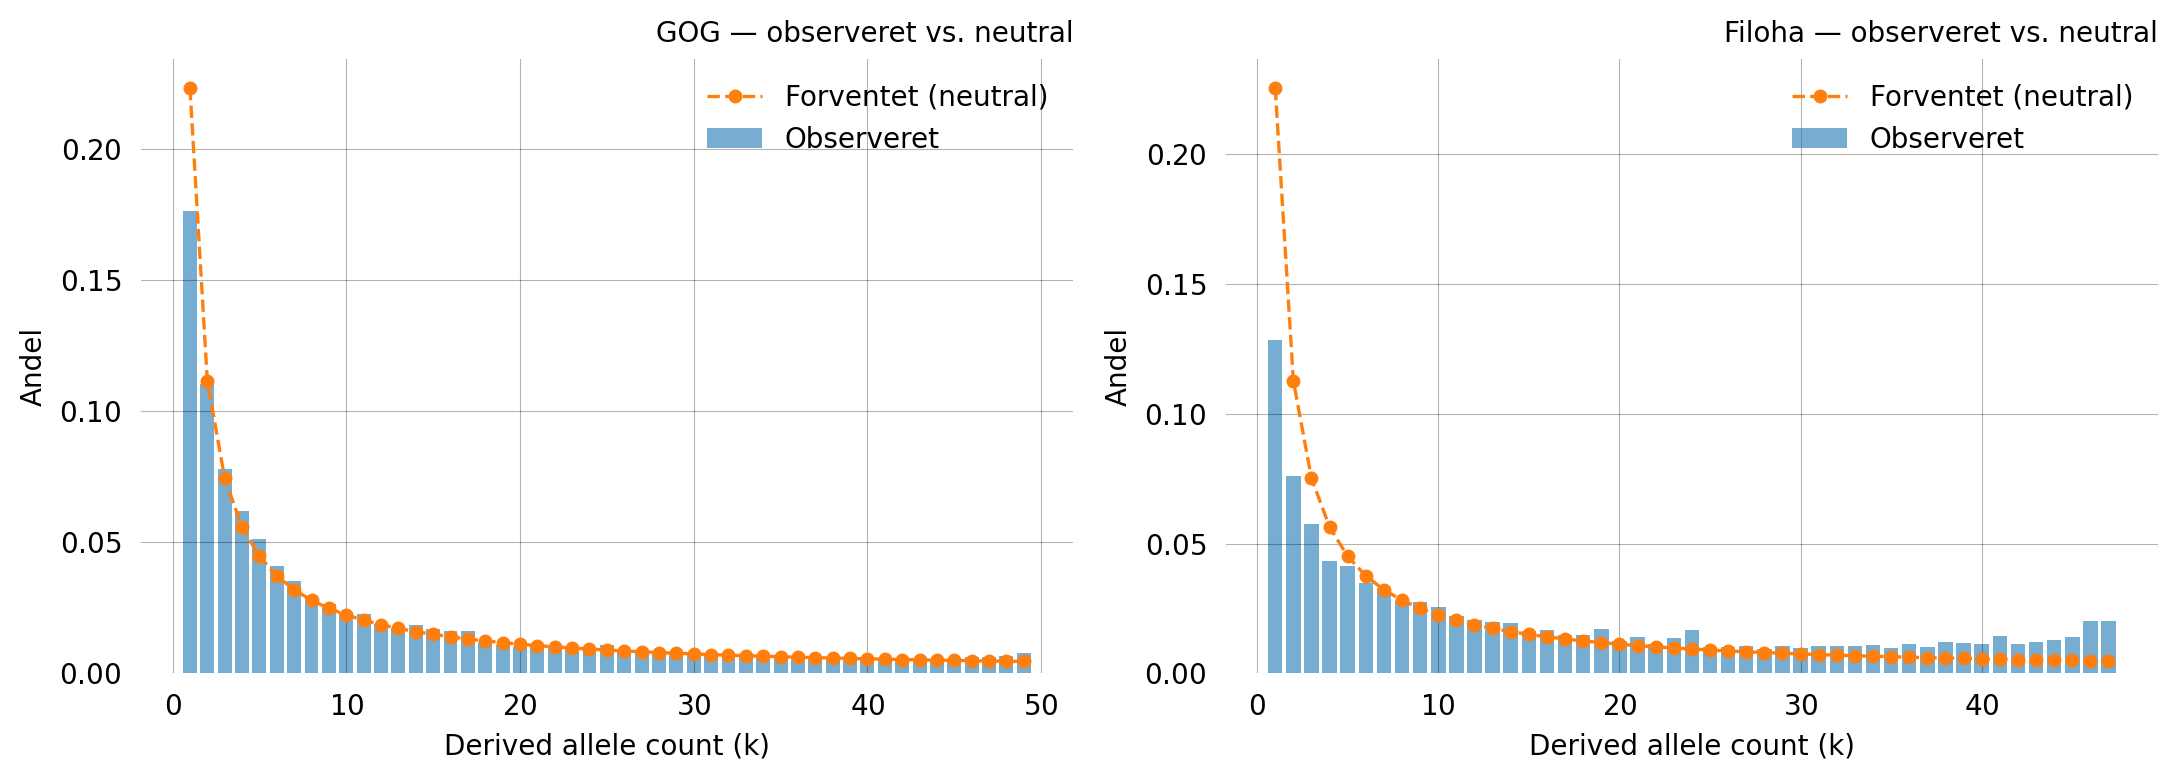

In [12]:
# Forventet SFS under standard neutral teori (Watterson 1975):
# E[SFS(k)] ∝ 1/k  (for k = 1, ..., n-1)
# Dette er den klassiske Ewens-Watterson-forventning

n_gog    = int(df_gog["nr_chromosomes"].iloc[0])
n_filoha = int(df_filoha["nr_chromosomes"].iloc[0])

def neutral_sfs(n):
    """Forventet normaliseret SFS under neutral model: proportional med 1/k."""
    k = np.arange(1, n)
    neutral = 1.0 / k
    return k, neutral / neutral.sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, sfs_obs, n, pop_name in [
    (axes[0], sfs_gog,    n_gog,    'GOG'),
    (axes[1], sfs_filoha, n_filoha, 'Filoha')
]:
    sfs_norm = normalize_sfs(sfs_obs)
    ax.bar(sfs_norm.index, sfs_norm.values, alpha=0.6, label='Observeret', color='C0')
    k_neutral, sfs_neutral = neutral_sfs(n)
    ax.plot(k_neutral, sfs_neutral, 'o--', color='C1', ms=4, lw=1.2, label='Forventet (neutral)')
    ax.set_xlabel("Derived allele count (k)")
    ax.set_ylabel("Andel")
    ax.set_title(f"{pop_name} — observeret vs. neutral")
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# Opsummerende statistik
print("=== Opsummering af de to populationer ===")
print()
for sfs_obs, df_obs, pop_name in [
    (sfs_gog,    df_gog,    'GOG'),
    (sfs_filoha, df_filoha, 'Filoha')
]:
    n = int(df_obs['nr_chromosomes'].iloc[0])
    total = sfs_obs.sum()
    singleton_frac = sfs_obs.get(1, 0) / total
    high_freq_frac = sfs_obs[sfs_obs.index > n // 2].sum() / total
    print(f"{pop_name}:")
    print(f"  Haploide kromosomer:      {n}")
    print(f"  Segregerende varianter:   {total:,}")
    print(f"  Andel singletons:         {singleton_frac:.1%}")
    print(f"  Andel høj-frekvens (>n/2): {high_freq_frac:.1%}")
    print()

=== Opsummering af de to populationer ===

GOG:
  Haploide kromosomer:      50
  Segregerende varianter:   528,250
  Andel singletons:         17.6%
  Andel høj-frekvens (>n/2): 15.7%

Filoha:
  Haploide kromosomer:      48
  Segregerende varianter:   460,025
  Andel singletons:         12.8%
  Andel høj-frekvens (>n/2): 27.5%



## 6. Forberedelse til modeltilpasning

Til de efterfølgende notebooks har jeg brug for SFS i et format, der kan bruges direkte med phasic's inferens-metoder. Jeg gemmer de tal jeg skal bruge.


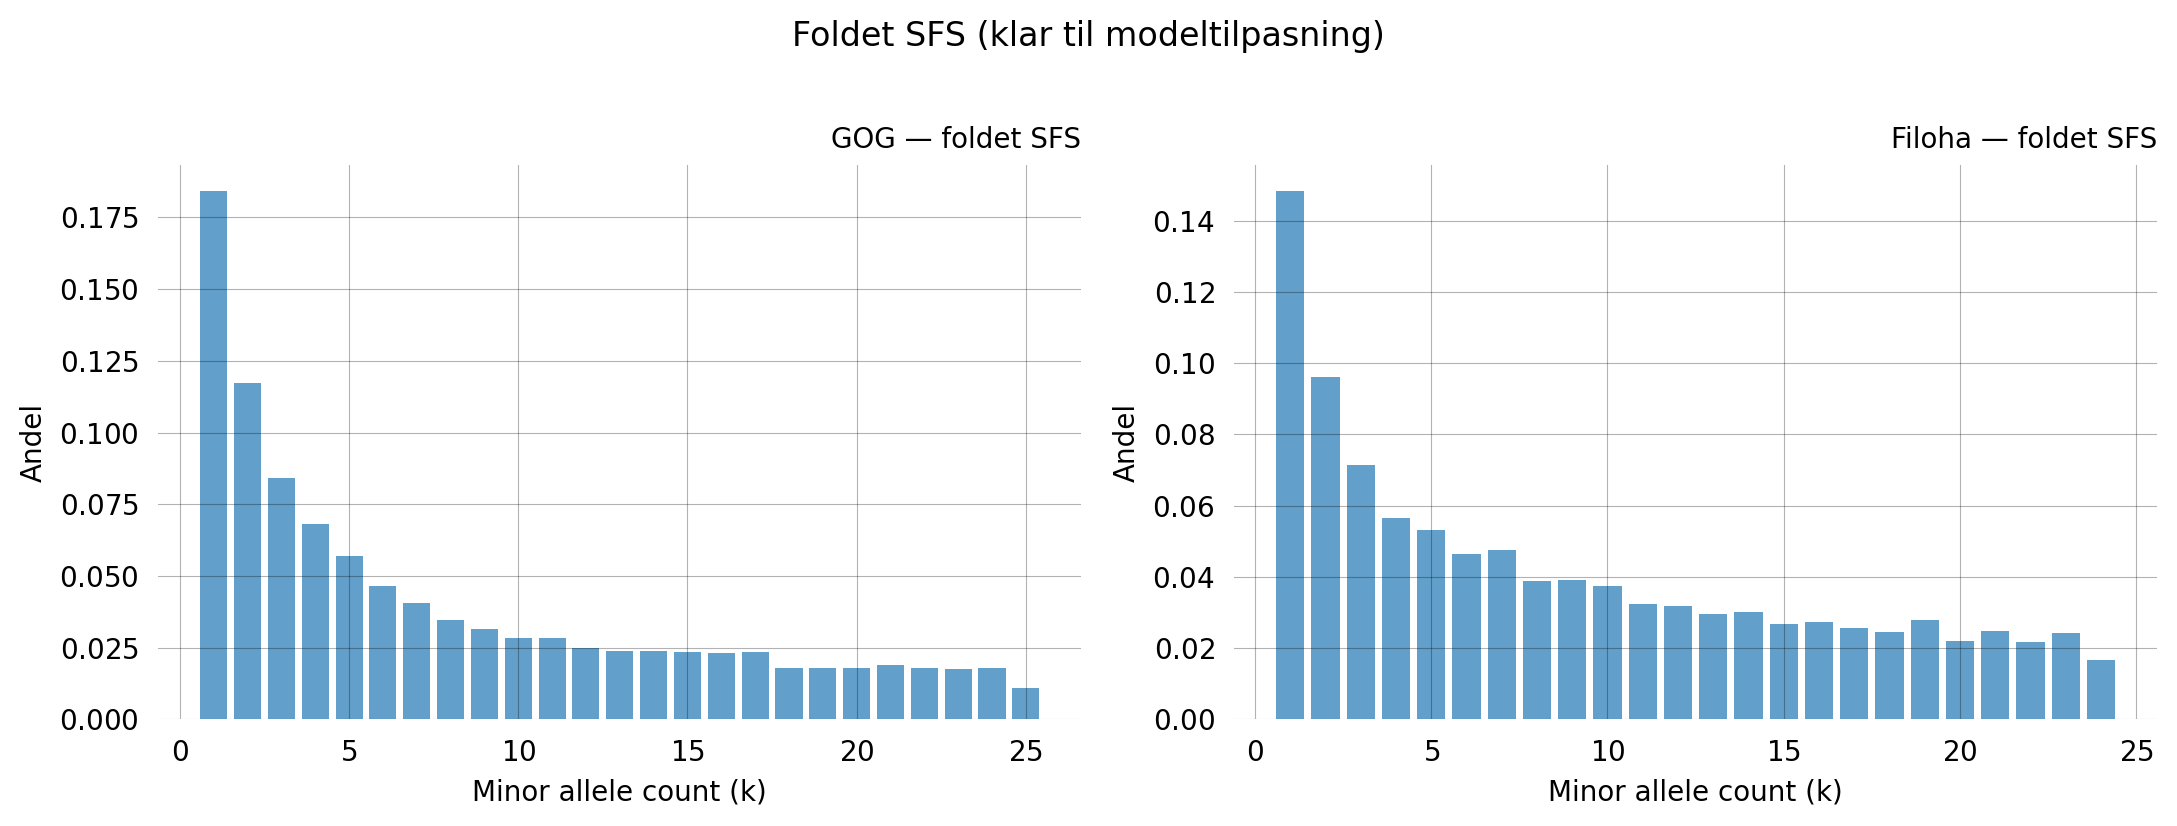

Foldet SFS gemt og klar til brug i Notebook 4+


In [14]:
def fold_sfs(sfs, n):
    """
    Fold SFS ved n/2: læg k og n-k sammen.
    Bruges når vi ikke er sikre på allelpolarisering.
    """
    folded = {}
    for k, count in sfs.items():
        key = min(k, n - k)
        folded[key] = folded.get(key, 0) + count
    return pd.Series(folded).sort_index()

folded_sfs_gog    = fold_sfs(sfs_gog,    n_gog)
folded_sfs_filoha = fold_sfs(sfs_filoha, n_filoha)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, sfs_folded, pop_name in [
    (axes[0], folded_sfs_gog,    'GOG'),
    (axes[1], folded_sfs_filoha, 'Filoha')
]:
    sfs_norm = sfs_folded / sfs_folded.sum()
    ax.bar(sfs_norm.index, sfs_norm.values, color='C0', alpha=0.7)
    ax.set_xlabel("Minor allele count (k)")
    ax.set_ylabel("Andel")
    ax.set_title(f"{pop_name} — foldet SFS")

plt.suptitle("Foldet SFS (klar til modeltilpasning)", y=1.02)
plt.tight_layout()
plt.show()

print("Foldet SFS gemt og klar til brug i Notebook 4+")

## Opsummering

Jeg har nu etableret datagrundlaget for resten af specialet:

| Trin | Resultat |
|---|---|
| Indlæst chr20 | ~varianter for >100 samples |
| Udtrukket GOG | 25 individer (*P. anubis*) |
| Udtrukket Filoha | 24 individer (*P. hamadryas*) |
| Beregnet DAC | Antal derived alleler per variant |
| Beregnet SFS | Fordeling af allelfrekvenser |
| Sammenlignet med neutral | Begge populationer afviger fra neutral forventning |

Sammenligningen med den neutrale forventning afslører strukturer i data. Afvigelserne kan skyldes demografiske events (bottlenecks, ekspansion, admixture) eller selektion. De næste notebooks kvantificerer disse afvigelser ved at tilpasse eksplicitte demografiske modeller.

I de næste notebooks, vil jeg komme ind på følgende:

- **Notebook 4** — Tidsinhomogene modeller: populationsstørrelsesskift over tid
- **Notebook 5** — IM-model: split + migration + ghost population
- **Notebook 6** — Two-island model: konstant migration uden split